# WITH SEABORN

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from collections import Counter
import warnings
warnings.filterwarnings('ignore') 

INSTRUCTIONS
1. Box and Swarm Plots in kill data
1. Most dangerous cities
1. Most dangerous states
1. Having mental ilness or not for killed people
1. Threat types
1. Flee types
<br>

In [2]:
kill = pd.read_csv('PoliceKillingsUS.csv', encoding="windows-1252")

In [3]:
kill.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


In [4]:
kill.shape

(2535, 14)

## 1a: Box plot of age in both genders separeted by manner of death.

In [5]:
kill.manner_of_death.unique()

array(['shot', 'shot and Tasered'], dtype=object)

**INSTRUCTION: Demonstrate the Qurtiles of age in both genders separeted by manner of death.**

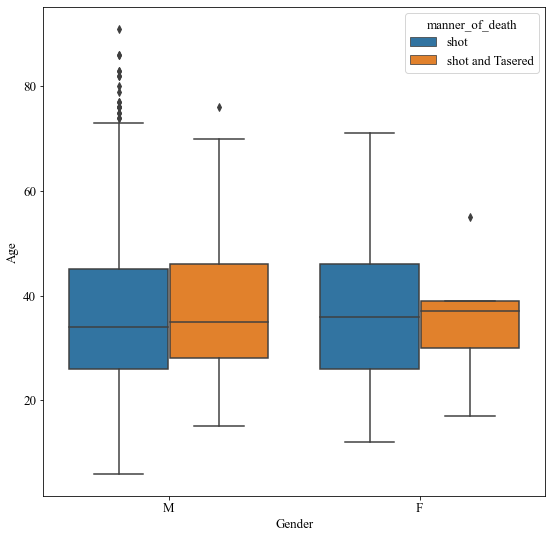

In [54]:
# with seaborn

fig, ax = plt.subplots(figsize=(9,9))

ax = sns.boxplot(x='gender', y='age', data=kill, hue='manner_of_death')
ax.set(xlabel = "Gender", ylabel = "Age")

plt.show()

## 1b: Swarm Plot 

**INSTRUCTION: Demonstrate the age in both genders separeted by manner of death by a swarm plot.**

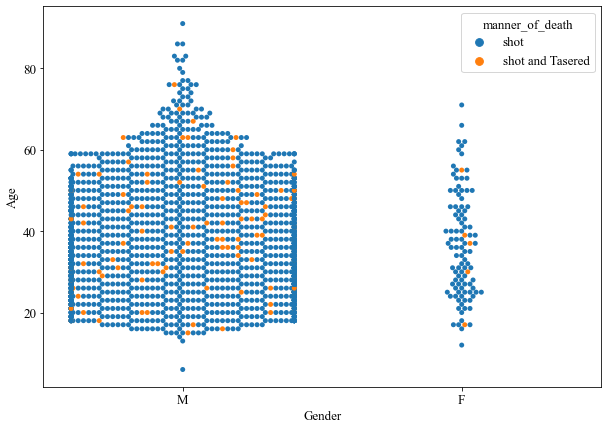

In [51]:
# with seaborn


fig, ax = plt.subplots(figsize=(10,7))

ax = sns.swarmplot(x='gender', y='age', data=kill, hue='manner_of_death')
ax.set(xlabel = "Gender", ylabel = "Age")
plt.show()

## 2: Plot 12 most dangerous cities

In [36]:
city_freq = pd.DataFrame(kill.city.value_counts().nlargest(12))
city_freq = city_freq.reset_index()
city_freq = city_freq.rename(columns={"index": "cities", "city": "counts"})
city_freq

,cities,counts
0,Los Angeles,39
1,Phoenix,31
2,Houston,27
3,Chicago,25
4,Las Vegas,21
5,San Antonio,20
6,Columbus,19
7,Austin,18
8,Miami,18
9,St. Louis,15


In [63]:
city_freq1 = kill.city.value_counts().nlargest(12)

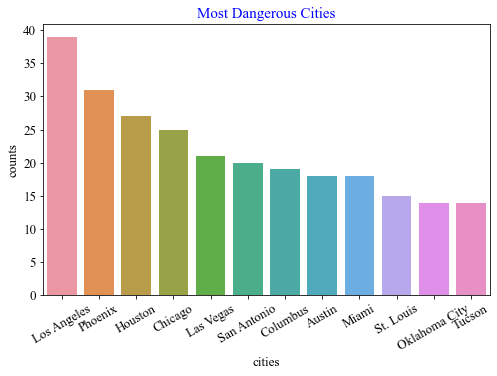

In [55]:
# with seaborn barplot
fig, ax =plt.subplots(figsize=(8,5))
ax = sns.barplot(x='cities', y='counts', data=city_freq)
ax.set_title('Most Dangerous Cities', fontsize = 15).set_color("blue")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
plt.show()

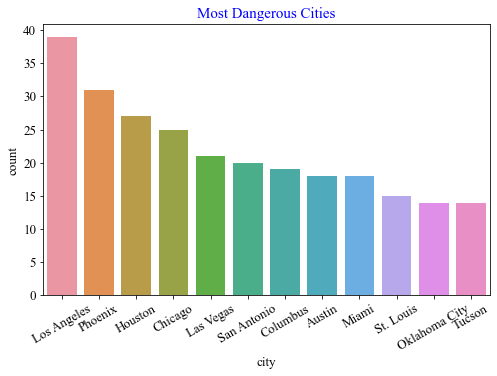

In [82]:
# with seaborn countplot
fig, ax =plt.subplots(figsize=(8,5))
sns.countplot(x=kill.city, data = city_freq1,order=kill.city.value_counts().iloc[:12].index)
ax.set_title('Most Dangerous Cities', fontsize = 15).set_color("blue")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
plt.show()

## 3: Plot 20 most dangerous states

In [69]:
state_freq = kill.state.value_counts().nlargest(20)
state_freq

CA    424
TX    225
FL    154
AZ    118
OH     79
OK     78
CO     74
GA     70
NC     69
MO     64
IL     62
WA     62
TN     59
LA     57
PA     51
NM     51
AL     50
VA     47
NY     45
SC     44
Name: state, dtype: int64

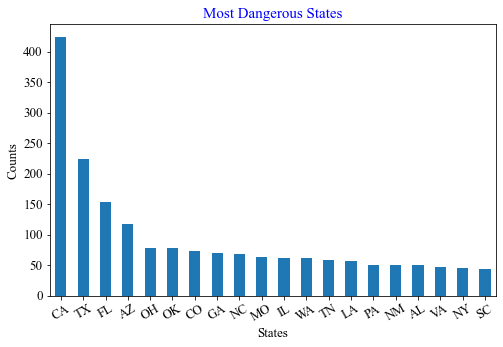

In [85]:
# with seaborn barplot
fig, ax =plt.subplots(figsize=(8,5))
ax = state_freq.plot(kind='bar')
ax.set_title('Most Dangerous States', fontsize = 15).set_color("blue")
ax.set(xlabel = "States", ylabel = "Counts")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
plt.show()

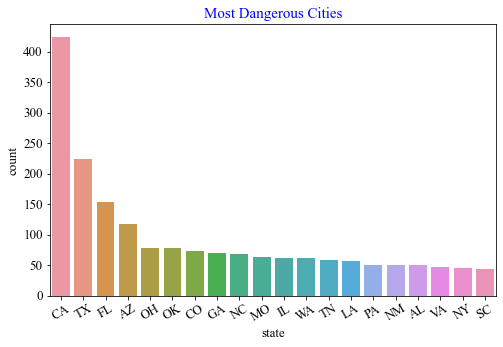

In [81]:
# with seaborn countplot
fig, ax =plt.subplots(figsize=(8,5))
sns.countplot(x=kill.state, data = state_freq, order=kill.state.value_counts().iloc[:20].index)
ax.set_title('Most Dangerous States', fontsize = 15).set_color("blue")
ax.set_xticklabels(ax.get_xticklabels(),rotation = 30)
plt.show()

## 4: Plot Having mental ilness or not for killed people

In [89]:
illness = pd.DataFrame(kill.signs_of_mental_illness.value_counts())
illness = illness.reset_index()
illness = illness.rename(columns={"index": "signs_of_mental_illness", "signs_of_mental_illness": "counts"})
illness

,signs_of_mental_illness,counts
0,False,1902
1,True,633


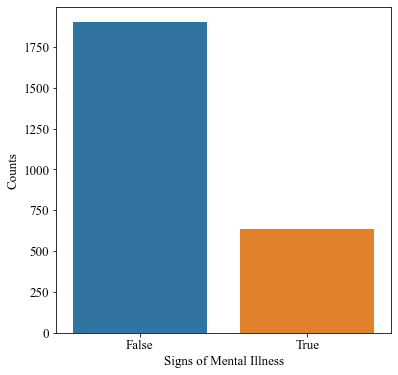

In [94]:
# with seaborn
fig, ax = plt.subplots(figsize=(6,6))

ax = sns.barplot(x='signs_of_mental_illness', y="counts", data=illness)
ax.set(xlabel = "Signs of Mental Illness", ylabel = "Counts")

plt.show()

## 5: Plot number of Threat Types

In [98]:
threads_freq = pd.DataFrame(kill.threat_level.value_counts())
threads_freq = threads_freq.reset_index()
threads_freq = threads_freq.rename(columns={"index": "threat_level", "threat_level": "counts"})
threads_freq

,threat_level,counts
0,attack,1611
1,other,766
2,undetermined,158


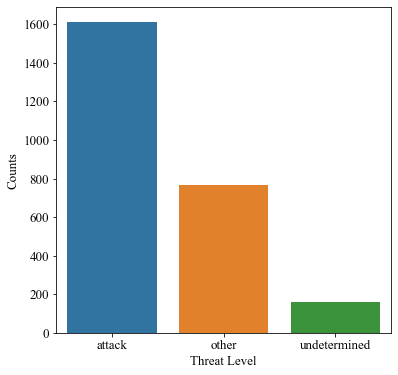

In [101]:
# with seaborn
fig, ax = plt.subplots(figsize=(6,6))

ax = sns.barplot(x='threat_level', y="counts", data=threads_freq)
ax.set(xlabel = "Threat Level", ylabel = "Counts")

plt.show()

## 6: Plot number of Flee Types

In [105]:
flee_freq = pd.DataFrame(kill.flee.value_counts())
flee_freq = flee_freq.reset_index()
flee_freq = flee_freq.rename(columns={"index": "flee", "flee": "counts"})
flee_freq

,flee,counts
0,Not fleeing,1695
1,Car,385
2,Foot,294
3,Other,96


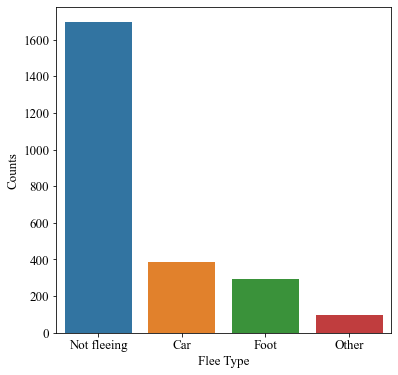

In [107]:
# with seaborn
fig, ax = plt.subplots(figsize=(6,6))

ax = sns.barplot(x='flee', y="counts", data=flee_freq)
ax.set(xlabel = "Flee Type", ylabel = "Counts")

plt.show()